<a href="https://colab.research.google.com/github/BALMEETCHADHA/STOCKS_ANALYSIS/blob/main/STOCK_MARKET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data

In [38]:
import yfinance as yf

In [39]:
start = '2019-01-01'
end = '2024-01-01'

df = yf.download('AAPL', start=start, end=end, auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503731,37.724594,36.627408,36.784150,148158800
2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


In [40]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-12-22,191.609451,193.400839,190.985924,193.173193,37149600
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300
2023-12-27,191.164108,191.510516,189.125291,190.510906,48087700
2023-12-28,191.589691,192.658589,191.183903,192.143931,34049900
2023-12-29,190.550461,192.401229,189.758683,191.906370,42672100


In [41]:
# Flatten MultiIndex columns to a single level for easier access
df.columns = df.columns.get_level_values('Price')

# Reset the index to make 'Date' a regular column
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.503731,37.724594,36.627408,36.784150,148158800
1,2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2,2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
3,2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
4,2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


In [42]:
print(df.columns)

# 'Date' column is now handled and 'Adj Close' is usually not present with auto_adjust=True.
# Ensure columns exist before attempting to drop them
columns_to_drop = ['Date', 'Adj Close']
cols_to_drop_actual = [col for col in columns_to_drop if col in df.columns]

if cols_to_drop_actual:
    df = df.drop(cols_to_drop_actual, axis=1)

df.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
0,37.503731,37.724594,36.627408,36.784150,148158800
1,33.768074,34.606398,33.722951,34.193172,365248800
2,35.209614,35.278487,34.150430,34.323794,234428400
3,35.131241,35.344980,34.649145,35.314106,219111200
4,35.800957,36.055068,35.271365,35.518348,164101200


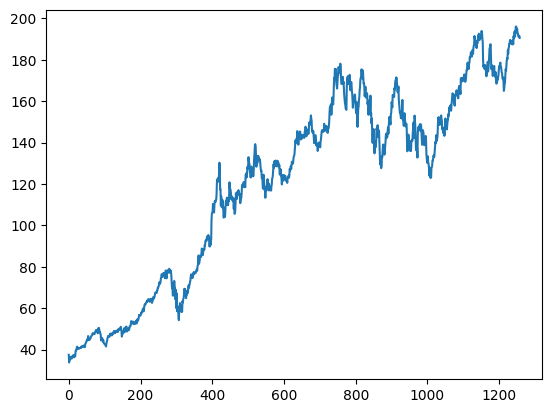

In [43]:
plt.plot(df.Close)

In [44]:
ma100=df.Close.rolling(100).mean()
ma100

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1253,179.723260
1254,179.746904
1255,179.862153
1256,180.012652


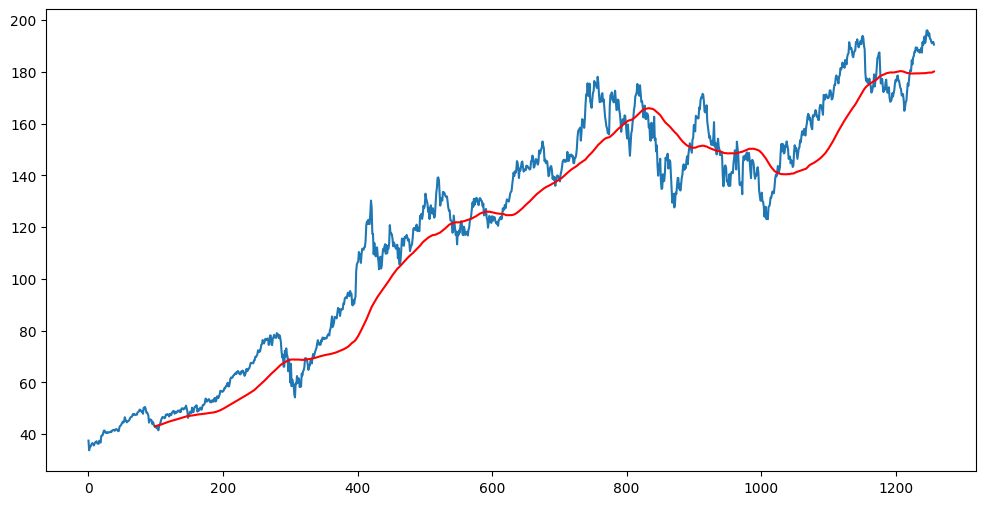

In [45]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [46]:
ma200=df.Close.rolling(200).mean()
ma200

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1253,176.443947
1254,176.667375
1255,176.881590
1256,177.087483


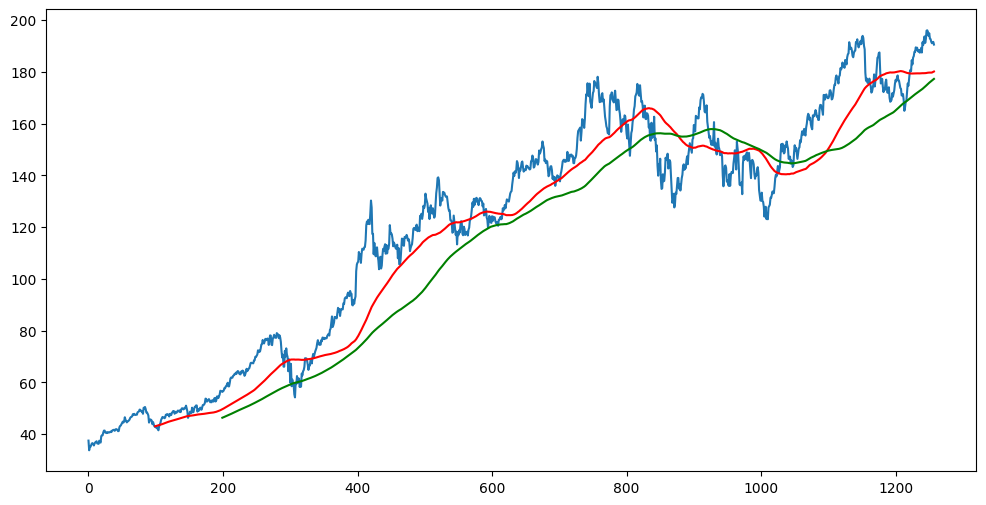

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')

In [48]:
df.shape

(1258, 5)

In [49]:
#Splitting Data into Training and Testing

data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(880, 1)
(378, 1)


In [50]:
data_training.head()

,Close
0,37.503731
1,33.768074
2,35.209614
3,35.131241
4,35.800957


In [51]:
data_testing.head()

,Close
880,134.152954
881,136.321457
882,138.902084
883,140.236557
884,143.602158


In [52]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [53]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.02588174],
       [0.        ],
       [0.00998742],
       [0.00944443],
       [0.01408442],
       [0.01829657],
       [0.01910274],
       [0.01661828],
       [0.01285032],
       [0.01790172],
       [0.02097849],
       [0.02249231],
       [0.02407183],
       [0.01828   ],
       [0.01930022],
       [0.01729281],
       [0.0256184 ],
       [0.02321618],
       [0.02055068],
       [0.03794228],
       [0.03990025],
       [0.04003192],
       [0.04781449],
       [0.05263547],
       [0.05273408],
       [0.0473044 ],
       [0.04763496],
       [0.04601552],
       [0.04842807],
       [0.04725485],
       [0.04827941],
       [0.04765153],
       [0.04849417],
       [0.05031185],
       [0.04870899],
       [0.05186511],
       [0.05394721],
       [0.0541125 ],
       [0.05500476],
       [0.05216252],
       [0.05516997],
       [0.05662408],
       [0.05609534],
       [0.05442632],
       [0.05108848],
       [0.05176597],
       [0.06166406],
       [0.064

In [54]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train=np.array(x_train),np.array(y_train)

In [55]:
#ML Model

from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

In [56]:
model=Sequential()
model.add(LSTM(units=50,activation='relu',return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='relu',return_sequences=True,))
model.add(Dropout(0.3))

model.add(LSTM(units=80,activation='relu',return_sequences=True,))
model.add(Dropout(0.4))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 281ms/step - loss: 0.1358
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0284
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0173
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0146
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0116
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0120
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0105
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0105
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0109
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0099
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0123
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0105
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0105
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0104
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0088
Ep

In [59]:
model.save('keras_model.h5')

In [60]:
past_100_days=data_training.tail(100)

In [61]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [62]:
final_df.head()

,Close
0,168.905075
1,168.189835
2,171.295746
3,172.716415
4,168.640503


In [63]:
input_data = scaler.fit_transform(final_df)
input_data

array([[6.27969195e-01],
       [6.18174908e-01],
       [6.60706320e-01],
       [6.80160540e-01],
       [6.24346224e-01],
       [5.77655468e-01],
       [5.80875585e-01],
       [6.33335848e-01],
       [6.30115731e-01],
       [5.80875585e-01],
       [5.59677056e-01],
       [5.19694825e-01],
       [4.62672783e-01],
       [4.98496297e-01],
       [5.26806204e-01],
       [5.30428549e-01],
       [5.04667822e-01],
       [5.49748624e-01],
       [5.45320989e-01],
       [5.04265804e-01],
       [4.52341914e-01],
       [4.27386686e-01],
       [5.01313768e-01],
       [4.41876899e-01],
       [3.91026800e-01],
       [3.35883838e-01],
       [3.95856662e-01],
       [4.56232967e-01],
       [4.70052453e-01],
       [5.15132836e-01],
       [5.33916956e-01],
       [5.80070504e-01],
       [5.98720269e-01],
       [6.50509178e-01],
       [6.59229884e-01],
       [6.71037189e-01],
       [7.16117990e-01],
       [7.00151760e-01],
       [6.57754493e-01],
       [6.53729295e-01],


In [64]:
input_data.shape

(478, 1)

In [65]:
x_test=[]
y_test=[]

for i in range(100 , input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [66]:
x_test,y_test=np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(378, 100, 1)
(378,)


In [67]:
#Making Predictions

y_predicted=model.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step


In [68]:
y_predicted.shape

(378, 1)

In [69]:
y_test

array([1.52084133e-01, 1.81778956e-01, 2.17117290e-01, 2.35391156e-01,
       2.81478675e-01, 2.90749963e-01, 2.61592139e-01, 2.74894684e-01,
       2.69923364e-01, 3.09963683e-01, 3.32806433e-01, 2.91153235e-01,
       3.43958682e-01, 3.71369272e-01, 4.02407848e-01, 3.85477734e-01,
       3.70159873e-01, 3.52020780e-01, 4.21756549e-01, 4.29280811e-01,
       4.98613517e-01, 4.85177244e-01, 4.65021999e-01, 5.47254605e-01,
       5.42954221e-01, 5.39859682e-01, 5.33401061e-01, 5.34074086e-01,
       5.92200426e-01, 5.82109222e-01, 6.30682819e-01, 6.45349176e-01,
       6.43196372e-01, 6.63648116e-01, 6.58266210e-01, 6.22878982e-01,
       5.69730650e-01, 5.65155706e-01, 5.69191979e-01, 6.02830301e-01,
       5.16581899e-01, 4.86442223e-01, 4.53207799e-01, 4.30468270e-01,
       4.40425329e-01, 4.11496513e-01, 3.94273871e-01, 4.13514963e-01,
       3.93332346e-01, 4.32486929e-01, 5.14025405e-01, 3.84989838e-01,
       4.04769183e-01, 3.65210283e-01, 3.42740507e-01, 3.93601054e-01,
      

In [70]:
scaler.scale_
a=scaler.scale_
a

array([0.0136937])

In [71]:
scale_factor=1/a
y_predicted=y_predicted*scale_factor
y_test=y_test*scale_factor

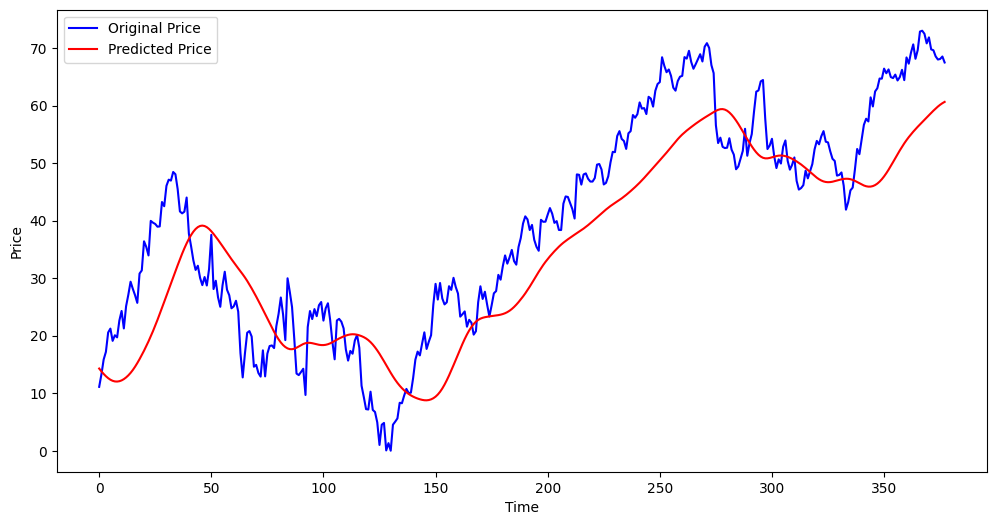

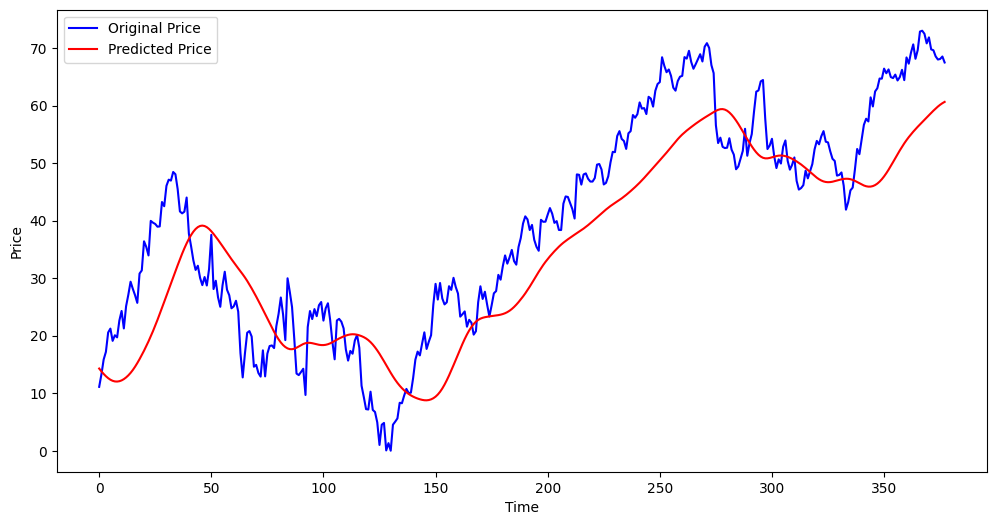

In [73]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()